# MAESTRO

In [1]:
%cd '/home/julia/Music/diploma/Rhythm_first_AMT'

/home/julia/Music/diploma/Rhythm_first_AMT


In [2]:
m_path = 'vec2vec_model/model_name v7.keras'
threshold = 0.5

In [3]:
# %pip install --upgrade --force-reinstall mirdata

In [4]:
import zipfile, os, shutil, sys, tempfile, subprocess, pretty_midi, librosa
from modules.global_vars import *

/home/julia/Music/diploma/Rhythm_first_AMT/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import matplotlib.pyplot as plt
from IPython.display import Audio

In [6]:
midi_dir = 'maestro_data_test_cut'
midi_dir2 = 'maestro_data_test_full'

In [7]:
fs = librosa.time_to_frames(1, sr=SR, hop_length=HOP_LENGTH)
fs

array(43)

In [8]:
def midi_to_pianoroll(midi_data, times, piano_range=(21, 109), fs=fs):
    raw_roll = midi_data.get_piano_roll(times=times, fs=fs)[piano_range[0]:piano_range[1], :]
    raw_roll = raw_roll.T
    binary_roll = (raw_roll > 0).astype(np.float32)
    onset_roll = binary_roll.copy()
    onset_roll[1:] = (raw_roll[1:] > raw_roll[:-1]).astype(np.float32)
    return raw_roll, binary_roll, onset_roll

In [9]:
def midi_to_notes(midi_data, start=0, end=None):

    notes = []

    # Iterate through instruments
    for instrument in midi_data.instruments:
        
        # Iterate through notes of each instrument
        for note in instrument.notes:
            if note.start >= start and (end is None or note.start < end):
                notes.append({
                    'pitch': note.pitch,  # MIDI number
                    'onset': note.start - start,
                    'offset': note.end - start
                })
    
    return notes

In [10]:
file_names = [
    s.split('.')[0] for s in os.listdir(midi_dir) if s.endswith('.mp3')
]

In [11]:
test_midi = file_names

In [12]:
frame_in_seconds = librosa.frames_to_time(1, sr=SR, hop_length=HOP_LENGTH)
frame_in_seconds

np.float64(0.023219954648526078)

In [13]:
p_rolls_ons = []

audio = []
onsets_list = []
notes_list = []

for iter, f in enumerate(test_midi):
    sys.stdout.write(f'\r Iteration {iter+1}/{len(test_midi)}')
    sys.stdout.flush()
    midi_path = f'{midi_dir}/{f}.midi'
    mp3_path = f'{midi_dir}/{f}.mp3'
    midi_data = pretty_midi.PrettyMIDI(midi_path)
    y_init, sr_init = librosa.load(mp3_path)
    y = librosa.resample(y=y_init, orig_sr=sr_init, target_sr=SR)

    start, end = 0, SR * 60
    y = y[start:end]
    dur_sec = y.shape[0] / SR

    times = np.arange(start / SR, end / SR, frame_in_seconds)
    p_raw, p_bin, p_ons = midi_to_pianoroll(midi_data, times=times)
    p_bin[p_ons == 1] = 2
    p_rolls_ons.append(p_ons)
    audio.append(y)
    notes = midi_to_notes(midi_data=midi_data, start=start / SR, end=end / SR)
    ons = np.array([note['onset'] for note in notes])
    onsets_list.append(ons)
    notes_list.append(notes)

 Iteration 10/10

# Our pipeline

In [14]:
from main import pipeline

I0000 00:00:1779438755.740786   16729 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779438755.785831   16729 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779438757.223042   16729 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [15]:
def extract_notes_from_piano_notes(piano_notes, onset_frames, offset_frames=None):  
    
    notes = []
    
    if offset_frames is None:
        offset_frames = onset_frames.copy()
        offset_frames[:-1] = onset_frames[1:]
        offset_frames[-1] += np.diff(onset_frames).mean()

    onset_times = librosa.frames_to_time(onset_frames)
    offset_times = librosa.frames_to_time(offset_frames)

    for piano_chord, onset, offset in zip(piano_notes, onset_times, offset_times):
        for pitch, is_on in enumerate(piano_chord):
            if is_on and offset > onset:
                notes.append({
                    'pitch': pitch + 21,  # MIDI number
                    'onset': onset,
                    'offset': offset
                })

    return notes

In [16]:
import mir_eval

In [17]:
def note_f1_prec_rec(pred_notes, true_notes, onset_tol=0.05, offset_ratio=None):
    
    refs = np.array([[n['onset'], n['offset'], n['pitch']] for n in true_notes])
    ests = np.array([[n['onset'], n['offset'], n['pitch']] for n in pred_notes])

    refs, ests = np.sort(refs, axis=0), np.sort(ests, axis=0)

    # step = 1000
    step = ests.shape[0]
    est_idxs = np.arange(0, ests.shape[0], step)

    f1_prec_rec_arr = np.zeros(6)

    for i in est_idxs:

        estimated_onsets = ests[i:i+step, 0]
        reference_onsets = refs[:, 0]
        bool_arr = (reference_onsets > estimated_onsets[0] - onset_tol) * (reference_onsets < estimated_onsets[-1] + onset_tol)

        ref_intervals, ref_pitches = refs[bool_arr, :2], refs[bool_arr, 2]
        est_intervals, est_pitches = ests[i:i+step, :2], ests[i:i+step, 2]

        scores = mir_eval.transcription.evaluate(
            ref_intervals, ref_pitches,
            est_intervals, est_pitches,
            onset_tolerance=onset_tol,
            pitch_tolerance=50.0,
            offset_ratio=offset_ratio
        )

        f1_pitched = scores['F-measure_no_offset']
        precision_pitched = scores['Precision_no_offset']
        recall_pitched = scores['Recall_no_offset']
        f1_unpitched = scores['Onset_F-measure']
        precision_unpitched = scores['Onset_Precision']
        recall_unpitched = scores['Onset_Recall']

        f1_prec_rec_arr += (f1_pitched, precision_pitched, recall_pitched, 
                            f1_unpitched, precision_unpitched, recall_unpitched)

    return list(f1_prec_rec_arr / est_idxs.shape[0])

In [18]:
arrays_pred = [pipeline(
    y_i, f'musicxml_folder/example{i}.musicxml', display_idx=-1, delay=0, 
    # onset_frames_init=None, 
    m_path=m_path, threshold=threshold
) for i, y_i in enumerate(audio)]

8/8 [==============================] - 0s 1ms/step


E0000 00:00:1779438764.929518   16729 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Notes found at onsets [  42   44   46   56   63   69   80   90   99  108  117  126  134  143
  152  163  177  187  196  206  214  222  230  238  246  252  260  285
  300  308  315  325  337  349  357  367  383  393  402  413  426  436
  445  456  464  472  481  489  497  502  512  538  553  557  571  581
  594  606  614  623  633  641  652  665  675  730  744  757  768  778
  787  798  808  818  826  836  844  854  865  876  885  894  902  911
  923  958  967  978  991 1004 1013 1022 1029 1039 1048 1065 1070 1074
 1084 1093 1101 1104 1115 1123 1131 1140 1149 1159 1170 1180 1228 1237
 1250 1266 1276 1286 1305 1314 1323 1333 1341 1351 1359 1372 1383 1393
 1402 1410 1419 1428 1437 1446 1453 1464 1472 1484 1497 1506 1515 1523
 1532 1539 1547 1556 1565 1575 1582 1593 1605 1615 1623 1631 1638 1646
 1654 1659 1664 1690 1718 1730 1745 1767 1774 1778 1858 1861 1865 1870
 1885 1897 1908 1919 1928 1938 1947 1956 1965 1974 1984 1997 2008 2017
 2028 2036 2044 2053 2061 2070 2078 2087 2119 2140 2154

In [19]:
ons_frames_pred = [a_pred[0] for a_pred in arrays_pred]
piano_notes_pred = [a_pred[1] for a_pred in arrays_pred]

In [20]:
idx = 7

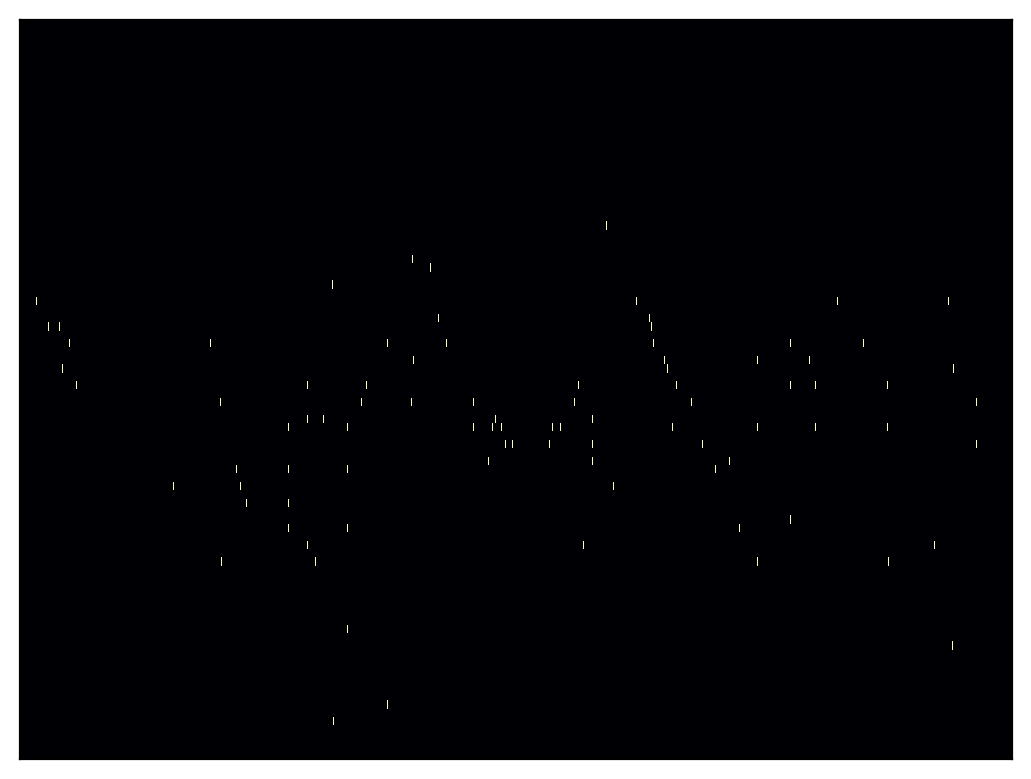

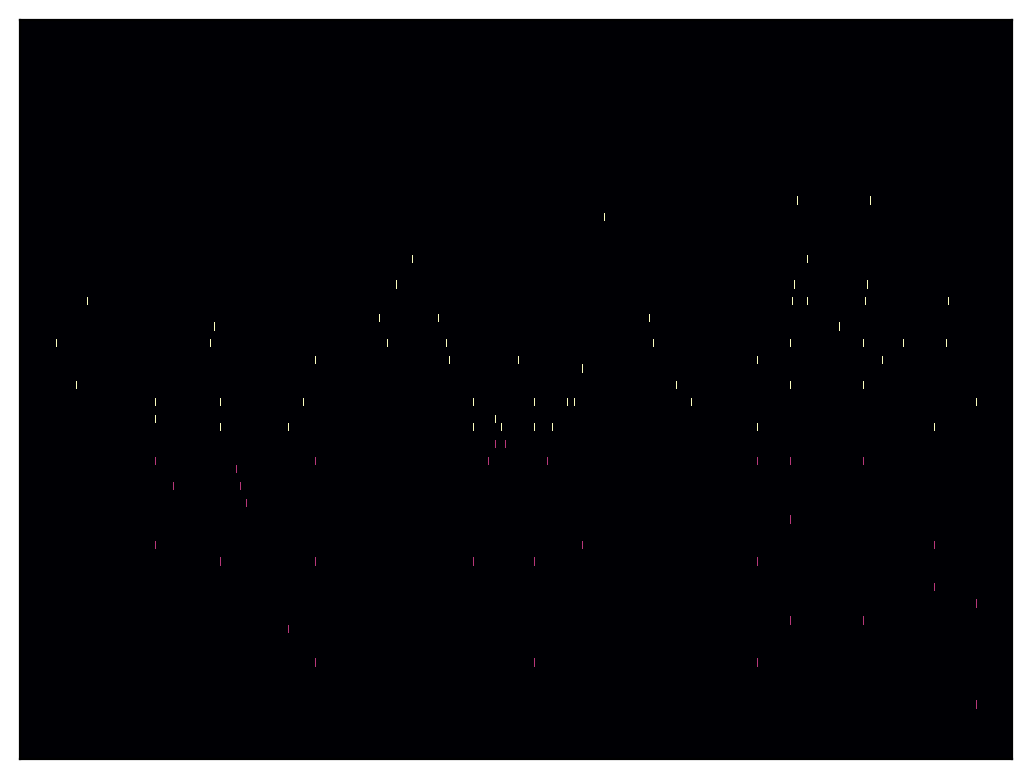

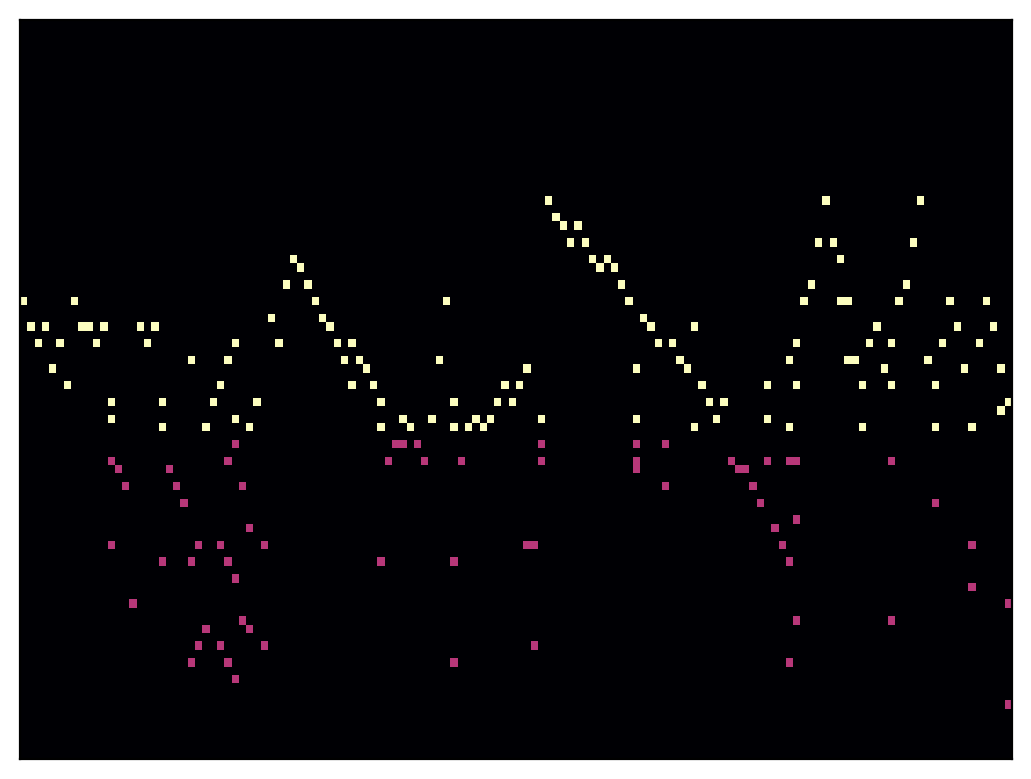

In [21]:
librosa.display.specshow((p_rolls_ons[idx].T > 0) * 1)
plt.show()
p_roll_pred = np.zeros_like(p_rolls_ons[idx])
p_roll_pred[ons_frames_pred[idx]] = piano_notes_pred[idx]
librosa.display.specshow(p_roll_pred.T)
plt.show()
librosa.display.specshow(piano_notes_pred[idx].T)
plt.show()

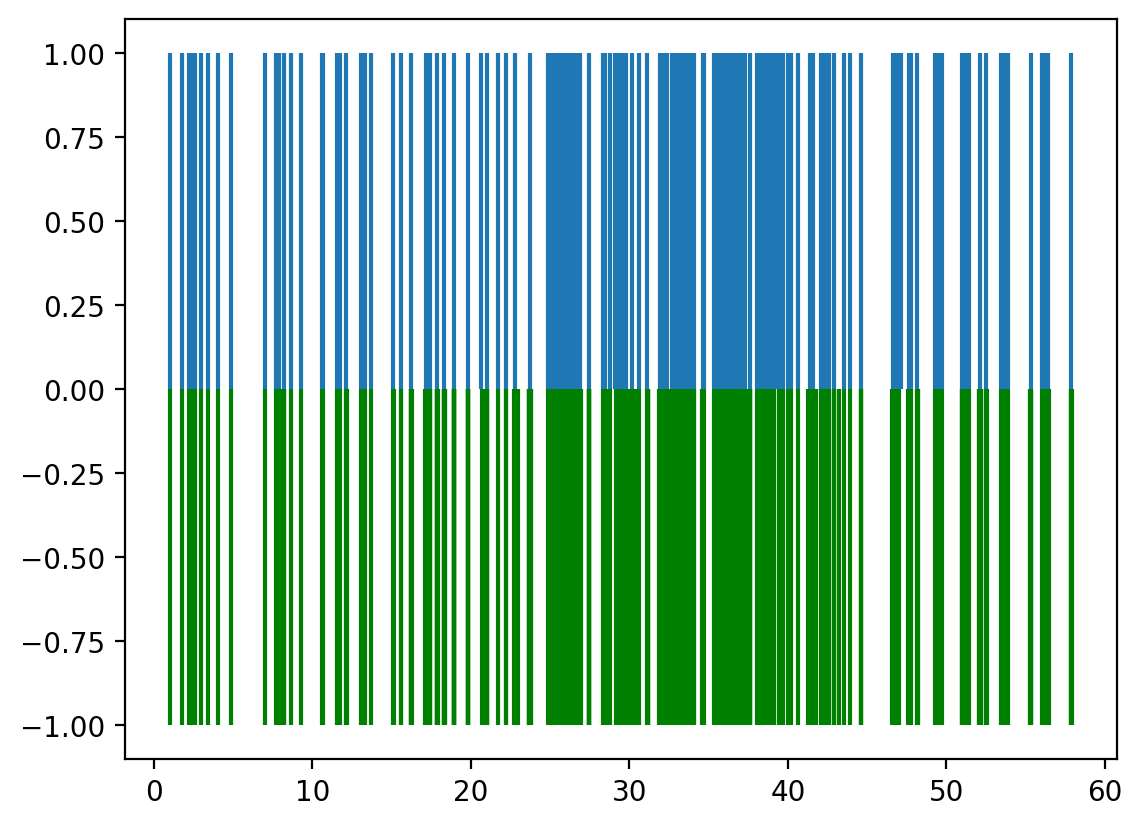

In [22]:
plt.vlines(librosa.frames_to_time(ons_frames_pred[idx], sr=SR, hop_length=HOP_LENGTH), 0, 1)
plt.vlines(onsets_list[idx], -1, 0, colors='green')

In [23]:
mp3_path = f'{midi_dir2}/{test_midi[idx]}.mp3'
y_init, sr_init = librosa.load(mp3_path)
y = librosa.resample(y=y_init, orig_sr=sr_init, target_sr=SR)
y = y[start:end]

In [24]:
# import os
# os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

# Comparing

In [25]:
import pandas as pd

In [59]:
df = pd.DataFrame(columns=[
    'Our pipeline', 'Onsets & Frames'
], index=[
    'Note F1', 'Note P', 'Note R', 
    'Unpitched F1', 'Unpitched P', 'Unpitched R', 
    'Beat F1', 'Beat P', 'Beat R'
])
df.index.name = 'Onset metrics'
df[:] = 0
count = len(test_midi)
all_metrics = np.zeros((df.shape[0], df.shape[1], count))

for i, (true_notes, ons_f_pred, pn_pred, f_name) in enumerate(zip(
    notes_list, ons_frames_pred, piano_notes_pred, test_midi
)):
    pred_dict = {}
    ons_pred_times = {}
    pred_dict[df.columns[0]] = extract_notes_from_piano_notes(piano_notes=pn_pred, onset_frames=ons_f_pred)
    midi_data = pretty_midi.PrettyMIDI(f'maestro_data_test_onsets_frames/{f_name}.mid')
    pred_dict[df.columns[1]] = midi_to_notes(midi_data, start=start / SR, end=end / SR)
    ons_pred_times[df.columns[0]] = librosa.frames_to_time(np.sort(ons_f_pred), sr=SR, hop_length=HOP_LENGTH)
    ons_pred_times[df.columns[1]] = np.sort([n['onset'] for n in pred_dict[df.columns[1]]])
    
    for idx_model, m_name in enumerate(df.columns[:2]):
        pred_notes = pred_dict[m_name]
        ons_pred_t = ons_pred_times[m_name]
        metrics_i = []
        order = np.lexsort((
            [n['pitch'] for n in true_notes], [n['onset'] for n in true_notes]
        ))
        metrics_i += note_f1_prec_rec(pred_notes, np.array(true_notes)[order], onset_tol=0.05)
        metrics_i += mir_eval.onset.f_measure(
            np.sort([n['onset'] for n in true_notes]),
            ons_pred_t,
            window=0.05
        )
        df[m_name] += metrics_i
        all_metrics[:, idx_model, i] = metrics_i

# all_metrics[:, 2] = all_metrics[:, 0] - all_metrics[:, 1]
# df['Difference'] = df['Our pipeline'] - df['Onsets & Frames']
df /= count

In [60]:
for col in df.columns:
    df[col] = df[col].round(3)

In [61]:
file_names

['MIDI-Unprocessed_02_R1_2006_01-04_ORIG_MID--AUDIO_02_R1_2006_02_Track02_wav',
 'MIDI-UNPROCESSED_01-03_R1_2014_MID--AUDIO_02_R1_2014_wav--1',
 'MIDI-Unprocessed_01_R1_2011_MID--AUDIO_R1-D1_03_Track03_wav',
 'MIDI-Unprocessed_01_R2_2006_01_ORIG_MID--AUDIO_01_R2_2006_03_Track03_wav',
 'ORIG-MIDI_01_7_10_13_Group_MID--AUDIO_02_R3_2013_wav--1',
 'MIDI-Unprocessed_01_R1_2009_01-04_ORIG_MID--AUDIO_01_R1_2009_01_R1_2009_01_WAV',
 'MIDI-Unprocessed_02_R1_2008_01-05_ORIG_MID--AUDIO_02_R1_2008_wav--1',
 'MIDI-Unprocessed_01_R1_2006_01-09_ORIG_MID--AUDIO_01_R1_2006_03_Track03_wav',
 'MIDI-UNPROCESSED_01-03_R1_2014_MID--AUDIO_01_R1_2014_wav--1',
 'MIDI-Unprocessed_01_R1_2006_01-09_ORIG_MID--AUDIO_01_R1_2006_01_Track01_wav']

In [62]:
m_path, threshold

('vec2vec_model/model_name v7.keras', 0.5)

In [63]:
our_str = df[['Our pipeline']].T
our_str.index
our_str

Onset metrics,Note F1,Note P,Note R,Unpitched F1,Unpitched P,Unpitched R,Beat F1,Beat P,Beat R
Our pipeline,0.704,0.754,0.664,0.866,0.926,0.818,0.68,0.964,0.534


In [64]:
df

,Our pipeline,Onsets & Frames
Onset metrics,,
Note F1,0.704,0.815
Note P,0.754,0.864
Note R,0.664,0.773
Unpitched F1,0.866,0.93
Unpitched P,0.926,0.987
Unpitched R,0.818,0.882
Beat F1,0.68,0.93
Beat P,0.964,0.987
Beat R,0.534,0.882


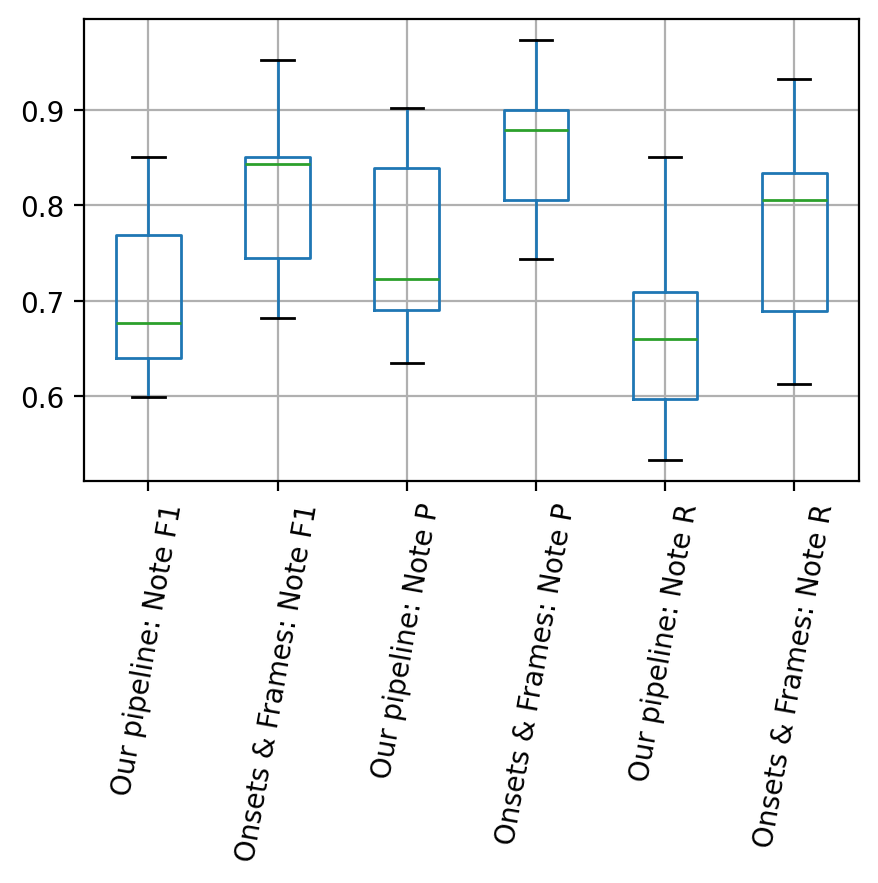

In [81]:
metric_idxs = range(3)
x_labels = [f'{col}: {idx}' for idx in df.index[metric_idxs] for col in df]
df_boxplot = pd.DataFrame(all_metrics[metric_idxs].reshape((-1, count)).T, columns=x_labels)

plt.figure(figsize=(5, 3))

df_boxplot.boxplot()

plt.xticks(rotation=80)
plt.show()

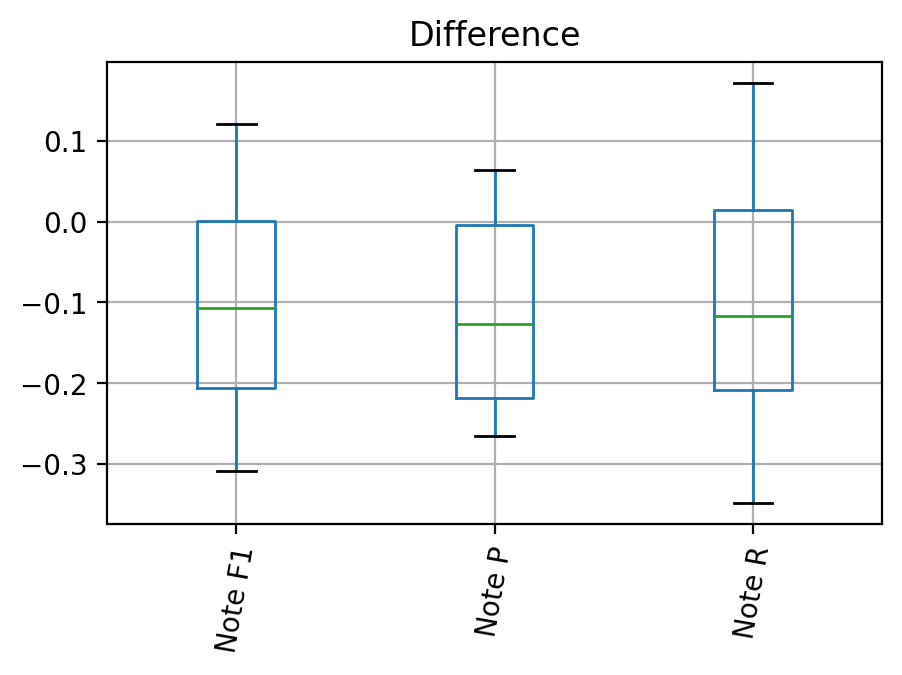

In [85]:
metric_idxs = range(3)
x_labels = [f'{idx}' for idx in df.index[metric_idxs]]
df_boxplot = pd.DataFrame((all_metrics[metric_idxs, 0] - all_metrics[metric_idxs, 1]).T, columns=x_labels)

plt.figure(figsize=(5, 3))

df_boxplot.boxplot()

plt.xticks(rotation=80)
plt.title('Difference')
plt.show()

In [33]:
Audio(y, rate=SR)

In [34]:
y_copy = y.copy()

In [35]:
click_sound, _ = librosa.load('audio_folder/mixkit-on-or-off-light-switch-tap-2585.wav', sr=SR)
click_sound = click_sound[20:125]
coeff = 1
click_sound *= (y.max() - y.min()) / coeff / (click_sound.max() - click_sound.min())
n = click_sound.shape[0]
# shift = n//2
shift = 20
for b in librosa.frames_to_samples(ons_frames_pred[idx], hop_length=HOP_LENGTH):
    x1 = max(b+shift-n, 0)
    x2 = min(max(b+shift, 0), y.shape[0])
    y_copy[x1:x2] += click_sound[:x2-x1] * 0.5
Audio(y_copy, rate=SR)

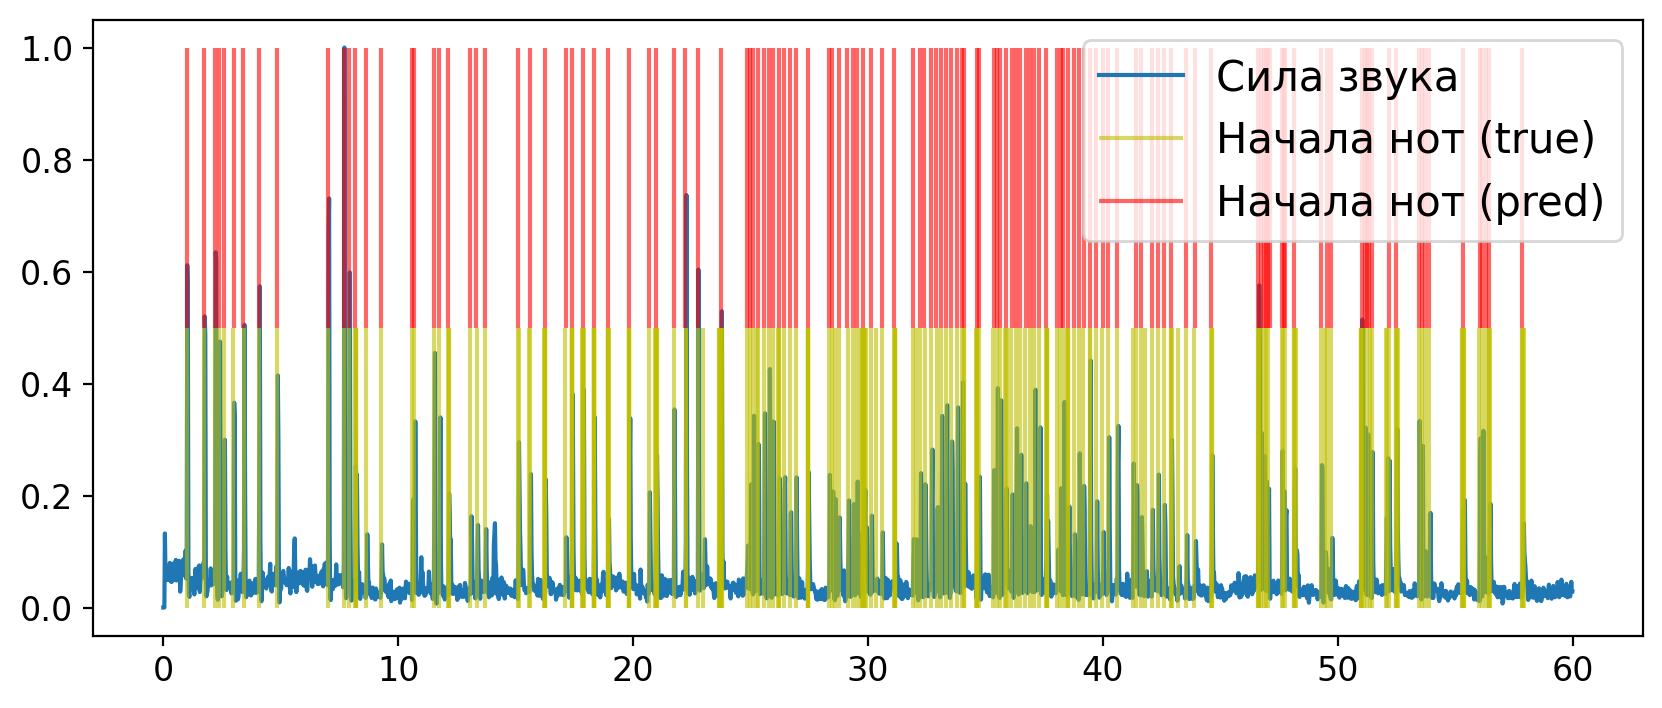

In [36]:
# cqt = np.abs(librosa.cqt(y_copy, sr=SR, fmin=NOTE_A_MIN, n_bins=N_BINS, bins_per_octave=BINS_PER_OCT,
#                          hop_length=HOP_LENGTH)).T
# diff_cqt = np.maximum(0, np.diff(np.concat([np.zeros((1, cqt.shape[1])), cqt]), axis=0))

# oenv = (diff_cqt).sum(axis=1)
oenv = librosa.onset.onset_strength(y=y, sr=SR, hop_length=HOP_LENGTH)
oenv /= oenv.max()

times = librosa.times_like(oenv, sr=SR, hop_length=HOP_LENGTH)

plt.figure(figsize=(10, 4))
plt.plot(times, oenv, label='Сила звука')
plt.vlines(onsets_list[idx], 0, oenv.max() / 2, color='y', alpha=0.6, 
           label='Начала нот (true)')
plt.vlines(librosa.frames_to_time(ons_frames_pred[idx], sr=SR, hop_length=HOP_LENGTH), 
           oenv.max() / 2, oenv.max(), color='r', alpha=0.6, label='Начала нот (pred)')
# plt.vlines(beat_times, 0, oenv.max(), color='r', alpha=0.6, label='Биты')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=15)
plt.show()